# **Введение**

***Привет, старался все сделать по блокам, в принципе все стандартно, думаю все будет ок, самое важное - это читать выводы, большие блоки можно скипать, но читать выводы (по желанию)***

# **Библиотеки**

In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker 
import seaborn as sns
import plotly.express as px
from collections import Counter
from wordcloud import WordCloud
from datasets import load_dataset

# Настройка эстетики, а че нам эстэтам
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# **EDA-анализ**

## **Загрузка датасета**

In [2]:
raw_dataset = load_dataset('Tobi-Bueck/customer-support-tickets', split='train')
df = raw_dataset.to_pandas()

df.head(3)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN


In [3]:
with open('data/train_idx.txt') as f:
    train_idx = [int(x) for x in f.read().strip().split('\n')]

with open('data/val_idx.txt') as f:
    val_idx = [int(x) for x in f.read().strip().split('\n')]

with open('data/test_idx.txt') as f:
    test_idx = [int(x) for x in f.read().strip().split('\n')]

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val   = df.iloc[val_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

In [ ]:
# # Если хочу сохранить датасет локально 
# dataset = load_dataset('Tobi-Bueck/customer-support-tickets', split='train')
# df = dataset.to_pandas()
# df.to_csv('customer_support_tickets.csv', index=False)          

## **Первичный базовый анализ**

In [13]:
df.shape

(61765, 16)

In [14]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   56466 non-null  str    
 1   body      61763 non-null  str    
 2   answer    48576 non-null  str    
 3   type      48587 non-null  str    
 4   queue     61765 non-null  str    
 5   priority  61765 non-null  str    
 6   language  61765 non-null  str    
 7   version   28587 non-null  float64
 8   tag_1     48587 non-null  str    
 9   tag_2     48528 non-null  str    
 10  tag_3     48356 non-null  str    
 11  tag_4     43990 non-null  str    
 12  tag_5     27636 non-null  str    
 13  tag_6     13225 non-null  str    
 14  tag_7     5968 non-null   str    
 15  tag_8     2472 non-null   str    
dtypes: float64(1), str(15)
memory usage: 57.2 MB


None

In [15]:
display(df.isnull().sum()) 

subject      5299
body            2
answer      13189
type        13178
queue           0
priority        0
language        0
version     33178
tag_1       13178
tag_2       13237
tag_3       13409
tag_4       17775
tag_5       34129
tag_6       48540
tag_7       55797
tag_8       59293
dtype: int64

In [16]:
print("\n--- Пропущенные значения ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
display(pd.DataFrame({"Кол-во n/a значений": missing, "Процент (%)": missing_pct}))


--- Пропущенные значения ---


,Кол-во n/a значений,Процент (%)
subject,5299,8.58
body,2,0.00
answer,13189,21.35
type,13178,21.34
queue,0,0.00
priority,0,0.00
language,0,0.00
version,33178,53.72
tag_1,13178,21.34
tag_2,13237,21.43


In [17]:
print("\n------- Дубликаты ------")
display(f"Дублированных строк: {df.duplicated().sum()}")



------- Дубликаты ------


'Дублированных строк: 0'

In [18]:
print("\n--- Уникальные значения по категориальным колонкам ---")
cat_cols = ["type", "queue", "priority", "language", "business_type"]
for col in cat_cols:
    if col in df.columns:
        display(f"{col}: {df[col].nunique()} уникальных --> {df[col].unique()[:10]}")



--- Уникальные значения по категориальным колонкам ---


"type: 4 уникальных --> <ArrowStringArray>\n['Incident', 'Request', 'Problem', 'Change', nan]\nLength: 5, dtype: str"

"queue: 52 уникальных --> <ArrowStringArray>\n[              'Technical Support',           'Returns and Exchanges',\n            'Billing and Payments',             'Sales and Pre-Sales',\n 'Service Outages and Maintenance',                 'Product Support',\n                      'IT Support',                'Customer Service',\n                 'Human Resources',                 'General Inquiry']\nLength: 10, dtype: str"

"priority: 5 уникальных --> <ArrowStringArray>\n['high', 'medium', 'low', 'very_low', 'critical']\nLength: 5, dtype: str"

"language: 2 уникальных --> <ArrowStringArray>\n['de', 'en']\nLength: 2, dtype: str"

In [19]:
print("\nА так будет выглядеть, если не буду брать только по избранным колонкам")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


А так будет выглядеть, если не буду брать только по избранным колонкам
subject: 46635
body: 53364
answer: 40139
type: 4
queue: 52
priority: 5
language: 2
version: 3
tag_1: 211
tag_2: 350
tag_3: 591
tag_4: 831
tag_5: 956
tag_6: 920
tag_7: 755
tag_8: 512


In [20]:
display(df['type'].value_counts(normalize=True) * 100)

type
Incident    40.018935
Request     28.711384
Problem     20.985037
Change      10.284644
Name: proportion, dtype: float64

In [21]:
display(df['queue'].value_counts().head(10))

queue
Technical Support                  14186
Product Support                     8960
Customer Service                    7420
IT Support                          5725
Billing and Payments                4874
Returns and Exchanges               2438
Service Outages and Maintenance     1912
Sales and Pre-Sales                 1490
Human Resources                      914
General Inquiry                      668
Name: count, dtype: int64

In [22]:
display(df['priority'].value_counts(normalize=True) * 100)

priority
medium      37.849915
high        35.497450
low         20.667044
critical     3.098842
very_low     2.886748
Name: proportion, dtype: float64

In [23]:
display(df['language'].value_counts(normalize=True) * 100)

language
de    54.244313
en    45.755687
Name: proportion, dtype: float64

In [24]:
display(df['version'].value_counts())

version
400.0    18599
52.0      9119
51.0       869
Name: count, dtype: int64

In [25]:
display(df['tag_1'].value_counts().head(10))

tag_1
Security       9156
Bug            7665
Feedback       5409
Technical      5034
Feature        4424
Performance    3865
Billing        2485
Outage         1755
Network        1482
Customer       1049
Name: count, dtype: int64

In [26]:
df['subject_length'] = df['subject'].str.len()
print(df['subject_length'].describe())

count    56466.000000
mean        47.396256
std         19.551640
min          3.000000
25%         35.000000
50%         45.000000
75%         57.000000
max        675.000000
Name: subject_length, dtype: float64


In [27]:
df['body_length'] = df['body'].str.len()
print(df['body_length'].describe())

count    61763.000000
mean       419.192996
std        223.850690
min          4.000000
25%        234.000000
50%        415.000000
75%        587.000000
max       2259.000000
Name: body_length, dtype: float64


In [28]:
df['answer_length'] = df['answer'].str.len()
print(df['answer_length'].describe())

count    48576.000000
mean       395.703022
std        198.998966
min          4.000000
25%        229.000000
50%        389.000000
75%        541.000000
max       1779.000000
Name: answer_length, dtype: float64


In [29]:
df['body_length'] = df['body'].str.len()

In [30]:
print("\nТип тикета vs Приоритет — доля по строке (% внутри каждого типа):")
print(pd.crosstab(df['type'], df['priority'], normalize='index') * 100)


Тип тикета vs Приоритет — доля по строке (% внутри каждого типа):
priority       high        low     medium
type                                     
Change    38.863318  20.532319  40.604363
Incident  43.494137  18.638140  37.867723
Problem   38.201255  20.615928  41.182817
Request   33.584229  22.917563  43.498208


In [31]:
print("\nТип тикета vs Язык — доля по строке (% внутри каждого типа):")
print(pd.crosstab(df['type'], df['language'], normalize='index') * 100)


Тип тикета vs Язык — доля по строке (% внутри каждого типа):
language         de         en
type                          
Change    40.164098  59.835902
Incident  42.331825  57.668175
Problem   42.183209  57.816791
Request   41.483871  58.516129


In [32]:
top_queues = df['queue'].value_counts().head(5).index
print("\nТоп‑5 очередей vs Язык — количество тикетов:")
print(pd.crosstab(df[df['queue'].isin(top_queues)]['queue'], df['language']))


Топ‑5 очередей vs Язык — количество тикетов:
language                de    en
queue                           
Billing and Payments  1977  2897
Customer Service      3151  4269
IT Support            2392  3333
Product Support       3655  5305
Technical Support     6037  8149


In [33]:
print("\nСредняя длина body по типам тикетов:")
print(df.groupby('type')['body_length'].mean())


Средняя длина body по типам тикетов:
type
Change      436.332399
Incident    380.641105
Problem     374.515253
Request     398.575914
Name: body_length, dtype: float64


In [34]:
print("\nТоп‑10 пар тегов (tag_1, tag_2):")
tag_pairs = df[['tag_1', 'tag_2']].dropna()
print(tag_pairs.value_counts().head(10))


Топ‑10 пар тегов (tag_1, tag_2):
tag_1      tag_2        
Bug        Performance      5129
Security   IT               2482
Feedback   Sales            2293
Feature    Documentation    1754
Billing    Payment          1507
Feature    Feedback         1399
Outage     Disruption       1281
Technical  Bug              1262
Feedback   Performance       985
Security   Bug               916
Name: count, dtype: int64


## **Чуть-чуть будем копать в категориальные переменные**

/var/folders/tp/h3xwbjzj52g1cjhylcmqhphr0000gn/T/ipykernel_61157/3751910652.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")
/var/folders/tp/h3xwbjzj52g1cjhylcmqhphr0000gn/T/ipykernel_61157/3751910652.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")
/var/folders/tp/h3xwbjzj52g1cjhylcmqhphr0000gn/T/ipykernel_61157/3751910652.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, pa

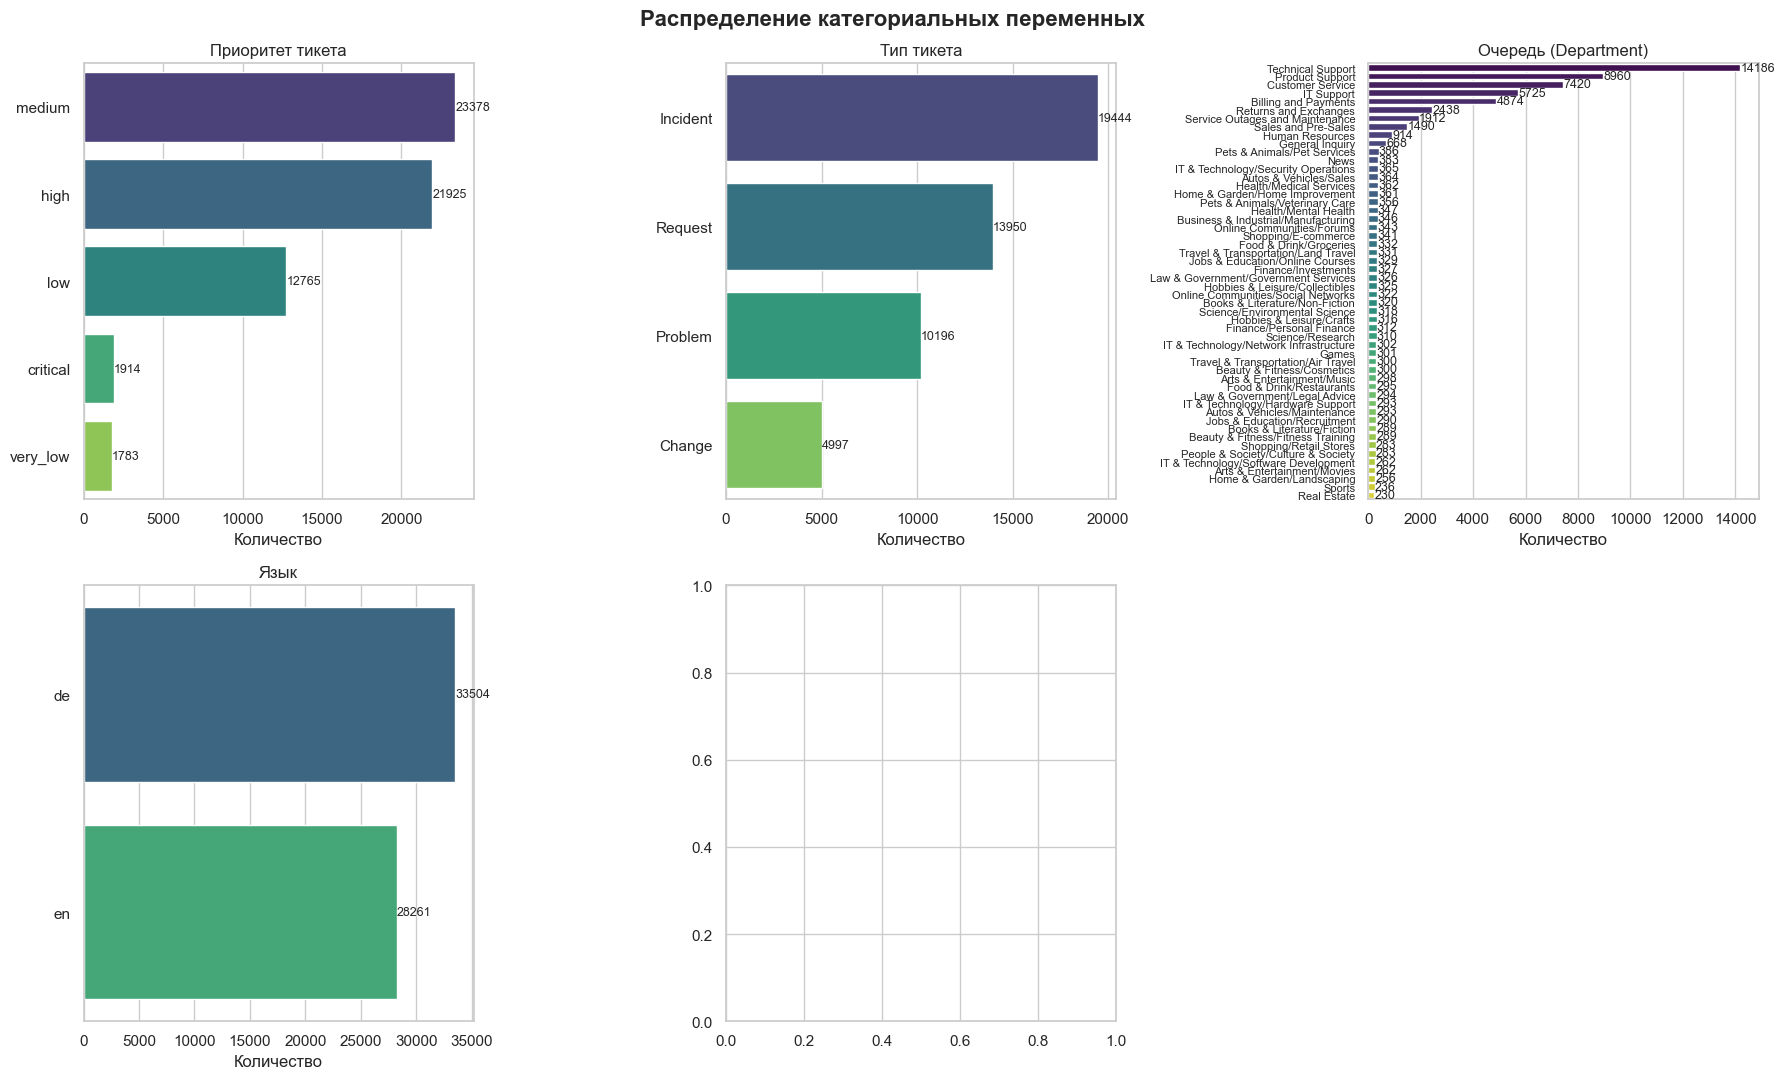

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Распределение категориальных переменных", fontsize=16, fontweight="bold")

cat_plot_cols = {
    "priority": "Приоритет тикета",
    "type": "Тип тикета",
    "queue": "Очередь (Department)",
    "language": "Язык",
    "business_type": "Тип бизнеса",
}

# Заполняем субплоты
for ax, (col, title) in zip(axes.flatten(), cat_plot_cols.items()):
    if col in df.columns:
        counts = df[col].value_counts()
        sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Количество")
        ax.set_ylabel("")
        for i, v in enumerate(counts.values):
            ax.text(v + 10, i, str(v), va="center", fontsize=9)
        # Если много категорий (как в queue), повернуть метки для читаемости
        if len(counts) > 10:
            ax.tick_params(axis='y', labelsize=8, rotation=0)  # Адаптируйте rotation если нужно

fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()


## **Чек тэги**

/var/folders/tp/h3xwbjzj52g1cjhylcmqhphr0000gn/T/ipykernel_61157/2484458394.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tags, x="count", y="tag", palette="magma", ax=ax)


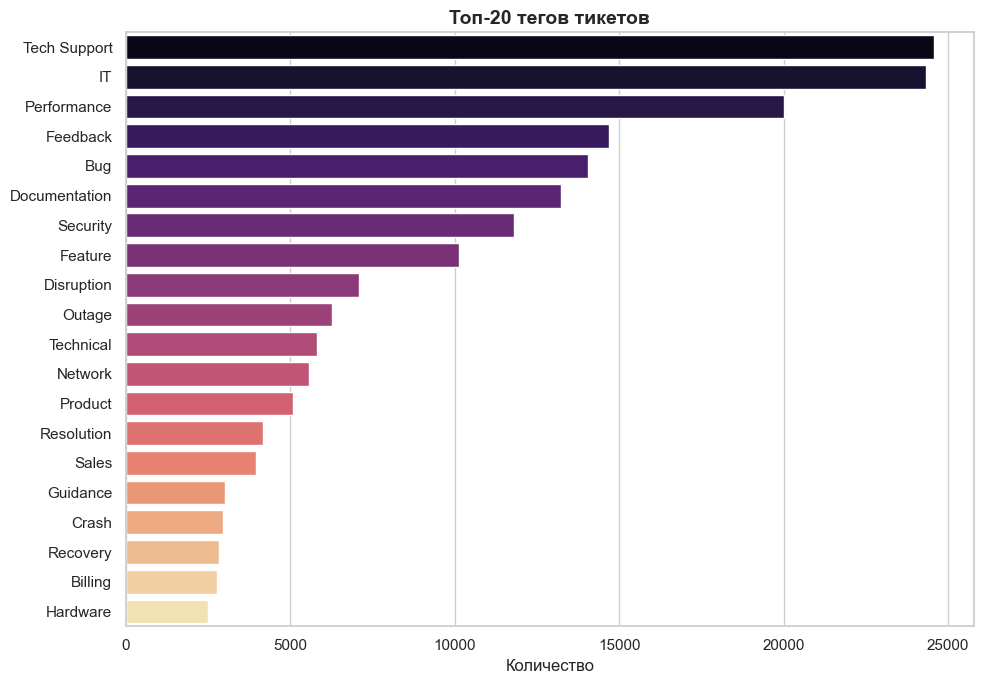

In [36]:
tag_cols = [c for c in df.columns if c.startswith("tag")]
all_tags = []
for col in tag_cols:
    if col in df.columns:
        all_tags.extend(df[col].dropna().tolist())

tag_counts = Counter(all_tags)
top_tags = pd.DataFrame(tag_counts.most_common(20), columns=["tag", "count"])

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top_tags, x="count", y="tag", palette="magma", ax=ax)
ax.set_title("Топ-20 тегов тикетов", fontsize=14, fontweight="bold")
ax.set_xlabel("Количество")
ax.set_ylabel("")
plt.tight_layout()
plt.show()



## **А чем там по длине текста?**

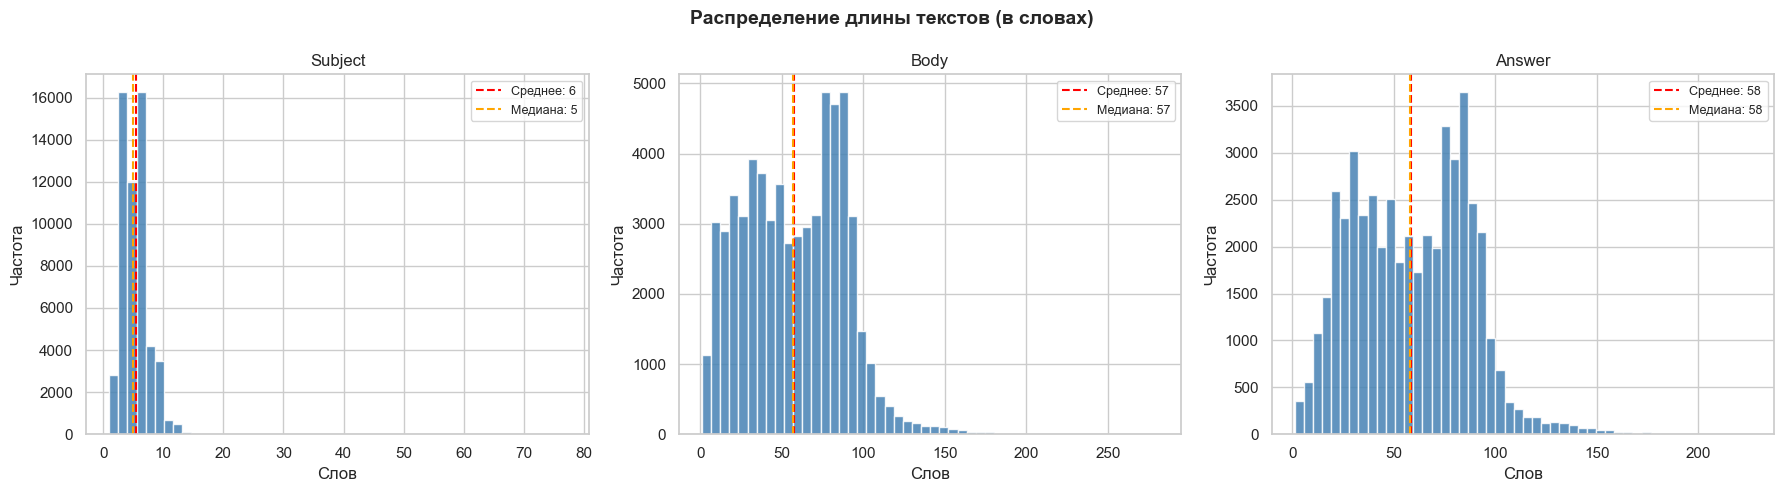

In [37]:
text_cols = ["subject", "body", "answer"]
for col in text_cols:
    if col in df.columns:
        df[f"{col}_len"] = df[col].dropna().apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Распределение длины текстов (в словах)", fontsize=14, fontweight="bold")

for ax, col in zip(axes, text_cols):
    len_col = f"{col}_len"
    if len_col in df.columns:
        data = df[len_col].dropna()
        ax.hist(data, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
        ax.axvline(data.mean(), color="red", linestyle="--", label=f"Среднее: {data.mean():.0f}")
        ax.axvline(data.median(), color="orange", linestyle="--", label=f"Медиана: {data.median():.0f}")
        ax.set_title(col.capitalize(), fontsize=12)
        ax.set_xlabel("Слов")
        ax.set_ylabel("Частота")
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## **Наиболее частые слова в Subject**

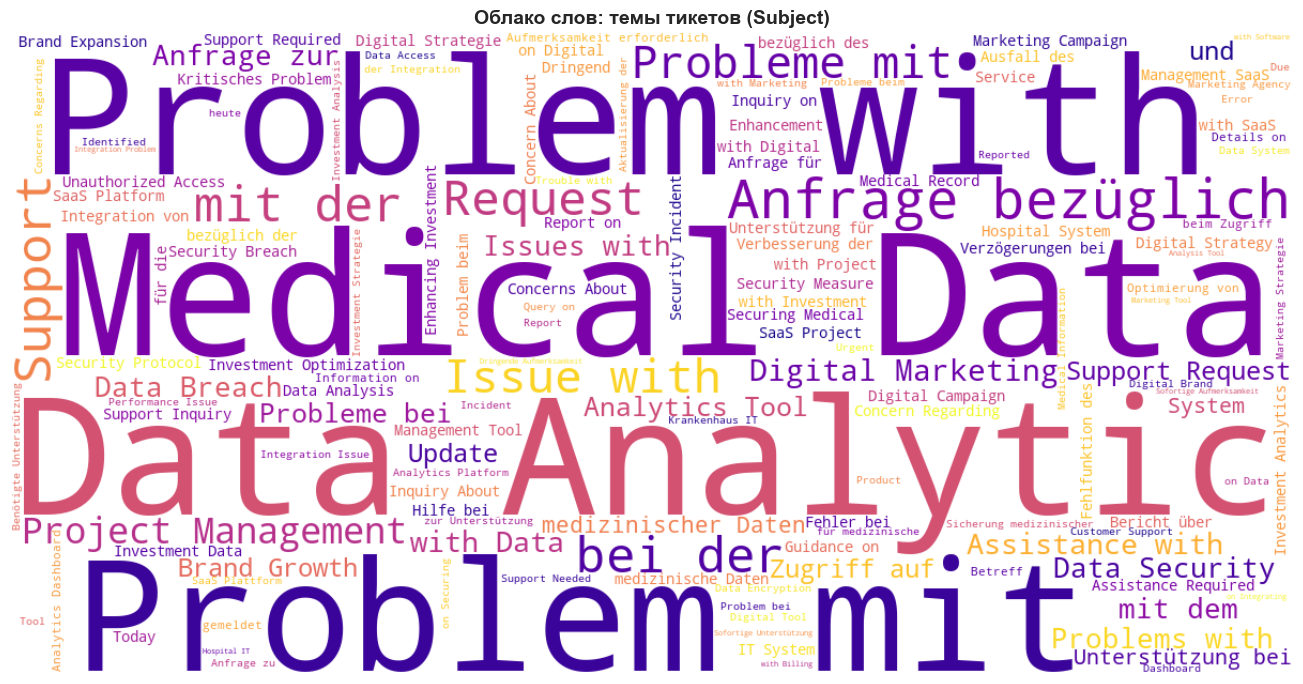

In [38]:
if "subject" in df.columns:
    text_all = " ".join(df["subject"].dropna().astype(str).tolist())
    wordcloud = WordCloud(
        width=1200, height=600,
        background_color="white",
        colormap="plasma",
        max_words=150,
        stopwords={"Dear", "the", "a", "of", "to", "and", "for", "is", "in", "I", "we"}
    ).generate(text_all)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(wordcloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Облако слов: темы тикетов (Subject)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


## **СВОДНАЯ СТАТИСТИКА ПО ДЛИНАМ ТЕКСТА**

In [39]:
print("\n--- Статистика по длинам текстов ---")
len_cols = [c for c in df.columns if c.endswith("_len")]
print(df[len_cols].describe().round(1))


--- Статистика по длинам текстов ---
       subject_len  body_len  answer_len
count      56466.0   61763.0     48576.0
mean           5.5      57.4        58.5
std            2.4      31.0        28.9
min            1.0       1.0         1.0
25%            4.0      31.0        34.0
50%            5.0      57.0        58.0
75%            7.0      82.0        81.0
max           77.0     281.0       226.0


## **РАСПРЕДЕЛЕНИЕ ПО ТИПУ ТИКЕТА × ПРИОРИТЕТ**

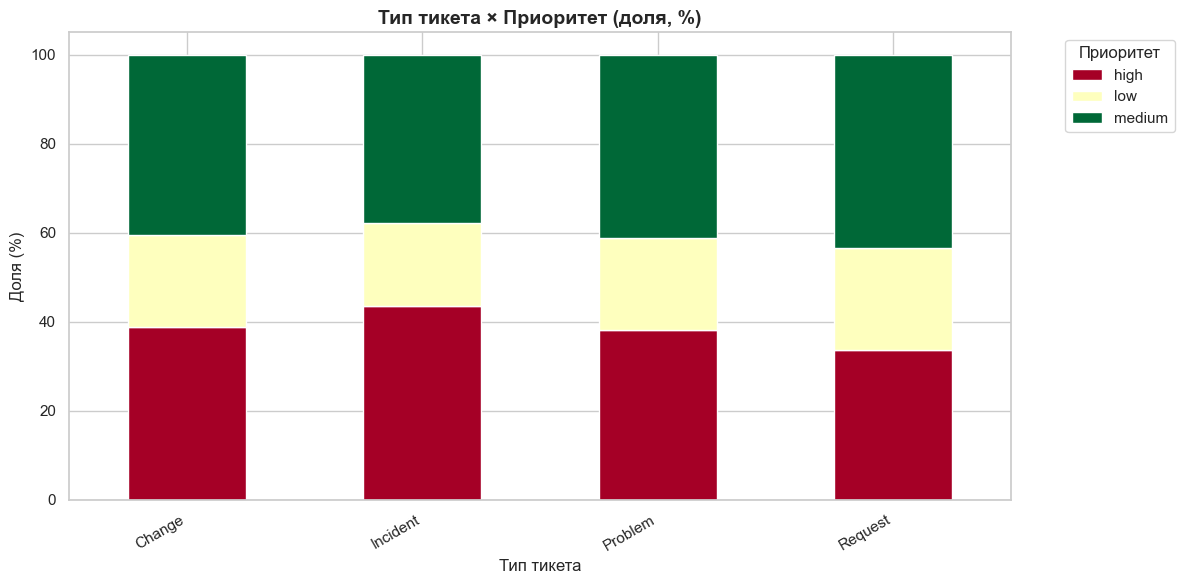

In [ ]:

if "type" in df.columns and "priority" in df.columns:
    stacked = pd.crosstab(df["type"], df["priority"], normalize="index") * 100
    stacked.plot(
        kind="bar", stacked=True, figsize=(12, 6),
        colormap="RdYlGn", edgecolor="white"
    )
    plt.title("Тип тикета × Приоритет (доля, %)", fontsize=14, fontweight="bold")
    plt.xlabel("Тип тикета")
    plt.ylabel("Доля (%)")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Приоритет", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## **Анализ дисбаланса классов queue** 

/var/folders/tp/h3xwbjzj52g1cjhylcmqhphr0000gn/T/ipykernel_61157/3955247010.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=queue_counts.values, y=queue_counts.index, ax=axes[0], palette="coolwarm")


Классов с < 100 примеров: 0
Классов с < 50 примеров: 0
Imbalance Ratio (max/min): 61.7x


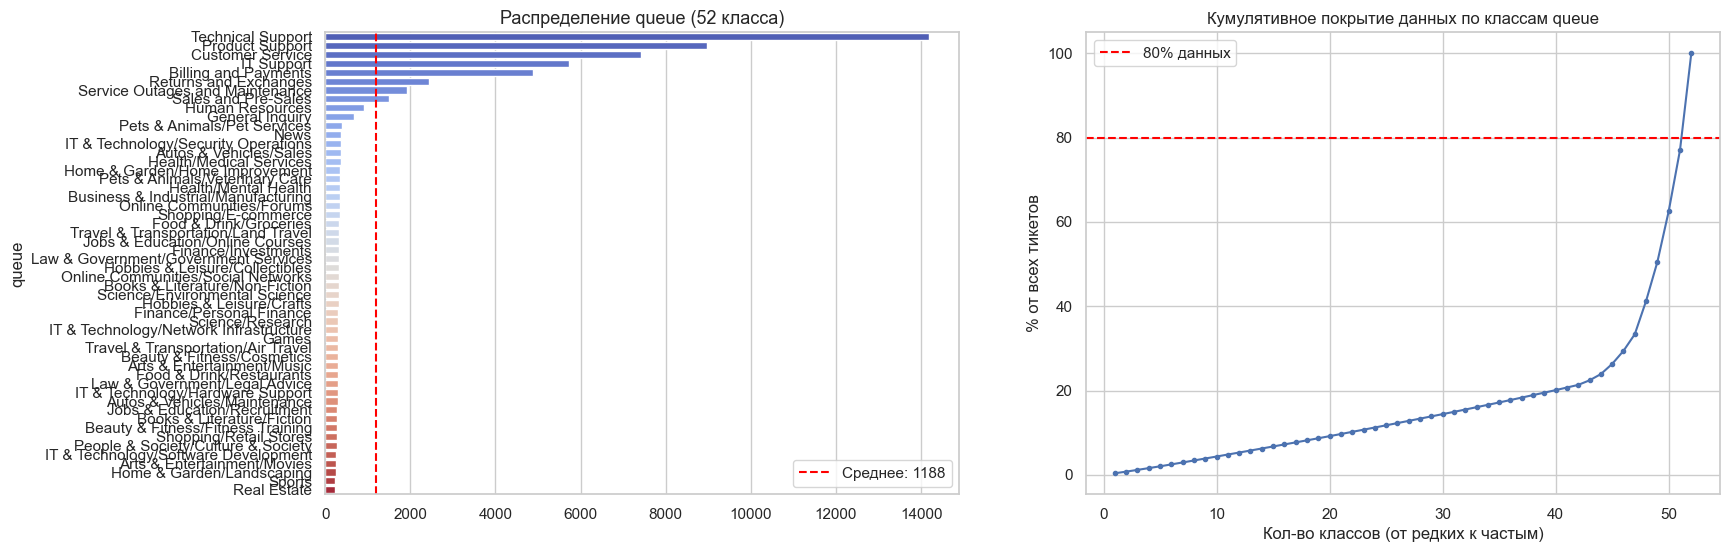

In [41]:

queue_counts = df["queue"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barplot — все 52 класса
sns.barplot(x=queue_counts.values, y=queue_counts.index, ax=axes[0], palette="coolwarm")
axes[0].set_title("Распределение queue (52 класса)", fontsize=13)
axes[0].axvline(queue_counts.mean(), color="red", linestyle="--", label=f"Среднее: {queue_counts.mean():.0f}")
axes[0].legend()

# Lorenz-style: кумулятивный % данных vs % классов
sorted_counts = np.sort(queue_counts.values)
cumsum = np.cumsum(sorted_counts) / sorted_counts.sum() * 100
axes[1].plot(range(1, len(sorted_counts)+1), cumsum, marker="o", markersize=3)
axes[1].axhline(80, color="red", linestyle="--", label="80% данных")
axes[1].set_title("Кумулятивное покрытие данных по классам queue")
axes[1].set_xlabel("Кол-во классов (от редких к частым)")
axes[1].set_ylabel("% от всех тикетов")
axes[1].legend()

# Сводка по редким классам
print(f"Классов с < 100 примеров: {(queue_counts < 100).sum()}")
print(f"Классов с < 50 примеров: {(queue_counts < 50).sum()}")
print(f"Imbalance Ratio (max/min): {queue_counts.max()/queue_counts.min():.1f}x")


## **Анализ длин текста для трансформеров** (BERT/RoBERTa имеют лимит 512 токенов. Нужно знать, сколько примеров его превышают)

Превышают 512 токенов: 0 (0.0%)
Превышают 256 токенов: 75 (0.1%)


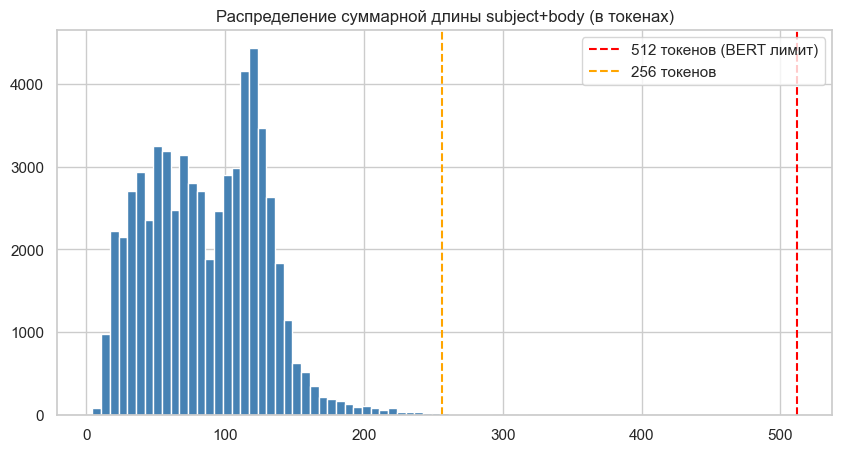

In [42]:

for col in ["subject", "body"]:
    if col in df.columns:
        df[f"{col}_tokens"] = df[col].fillna("").apply(lambda x: len(x.split()) / 0.75)

df["total_tokens"] = df["subject_tokens"] + df["body_tokens"] + 3  # [CLS] + [SEP] + [SEP]

print(f"Превышают 512 токенов: {(df['total_tokens'] > 512).sum()} ({(df['total_tokens'] > 512).mean()*100:.1f}%)")
print(f"Превышают 256 токенов: {(df['total_tokens'] > 256).sum()} ({(df['total_tokens'] > 256).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["total_tokens"].clip(upper=700), bins=60, color="steelblue", edgecolor="white")
ax.axvline(512, color="red", linestyle="--", label="512 токенов (BERT лимит)")
ax.axvline(256, color="orange", linestyle="--", label="256 токенов")
ax.set_title("Распределение суммарной длины subject+body (в токенах)")
ax.legend()


## **Корреляция меток** (Понять зависимости между тремя целевыми переменными)

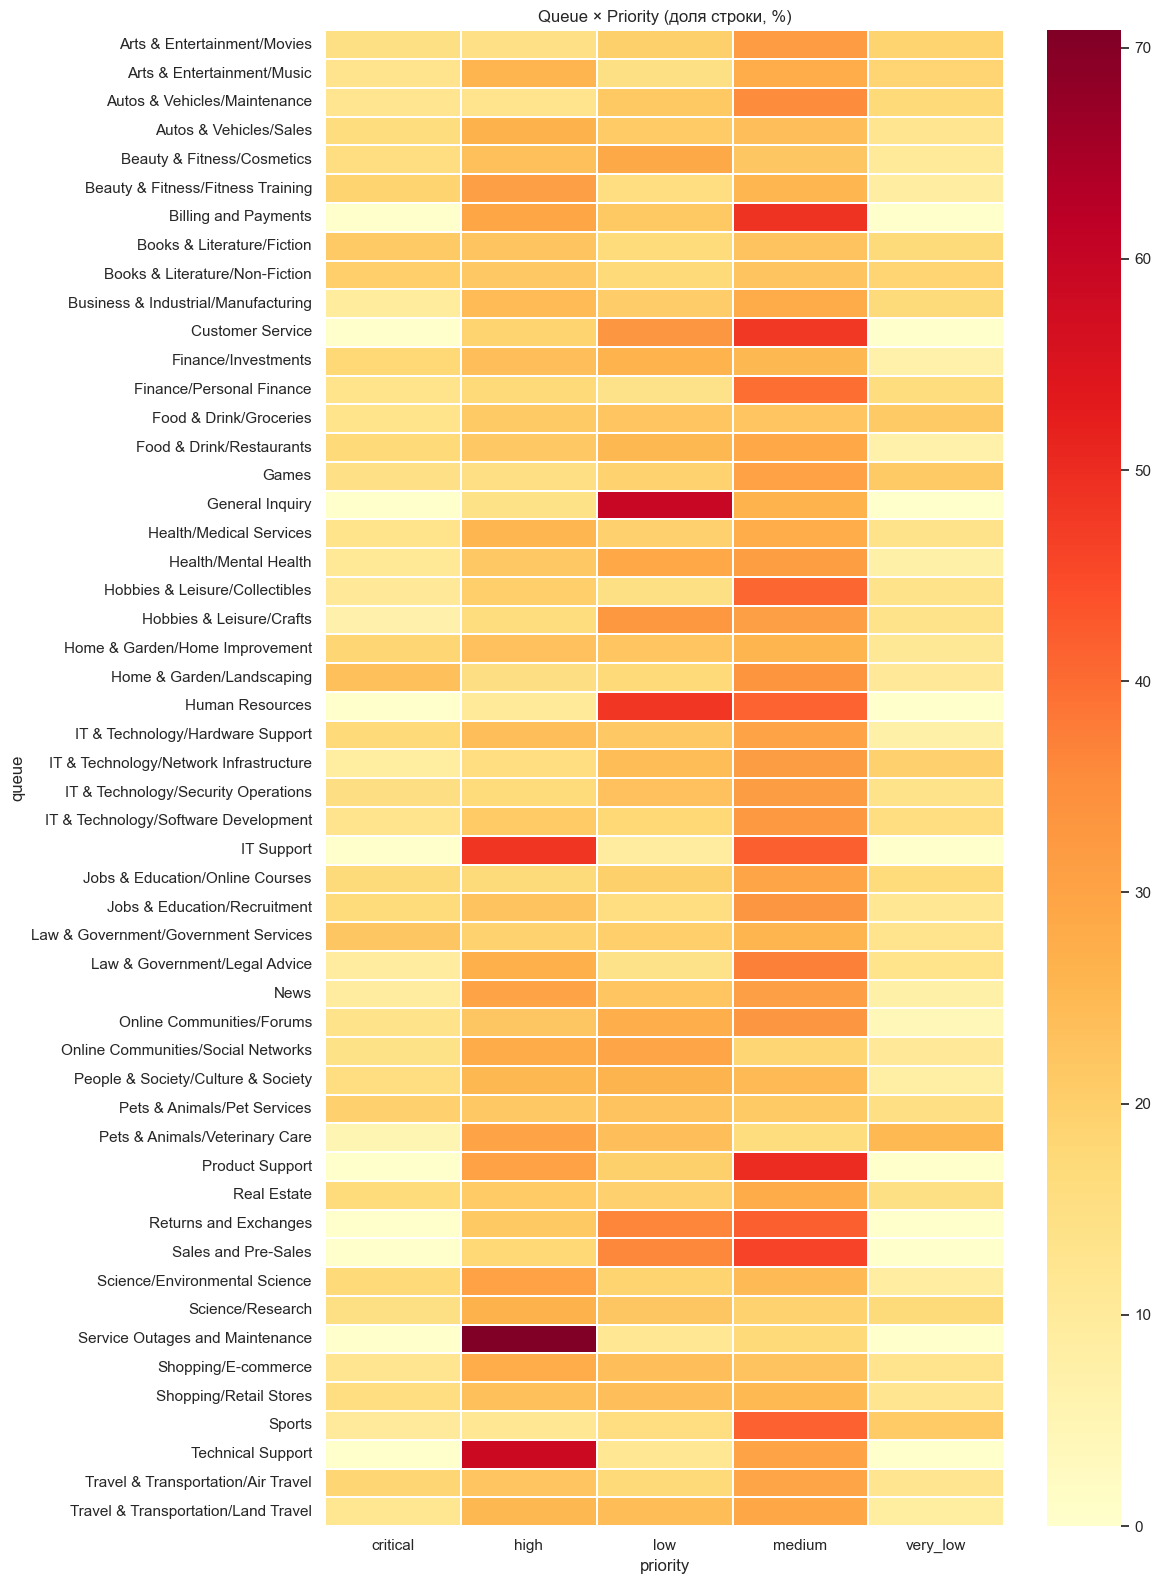

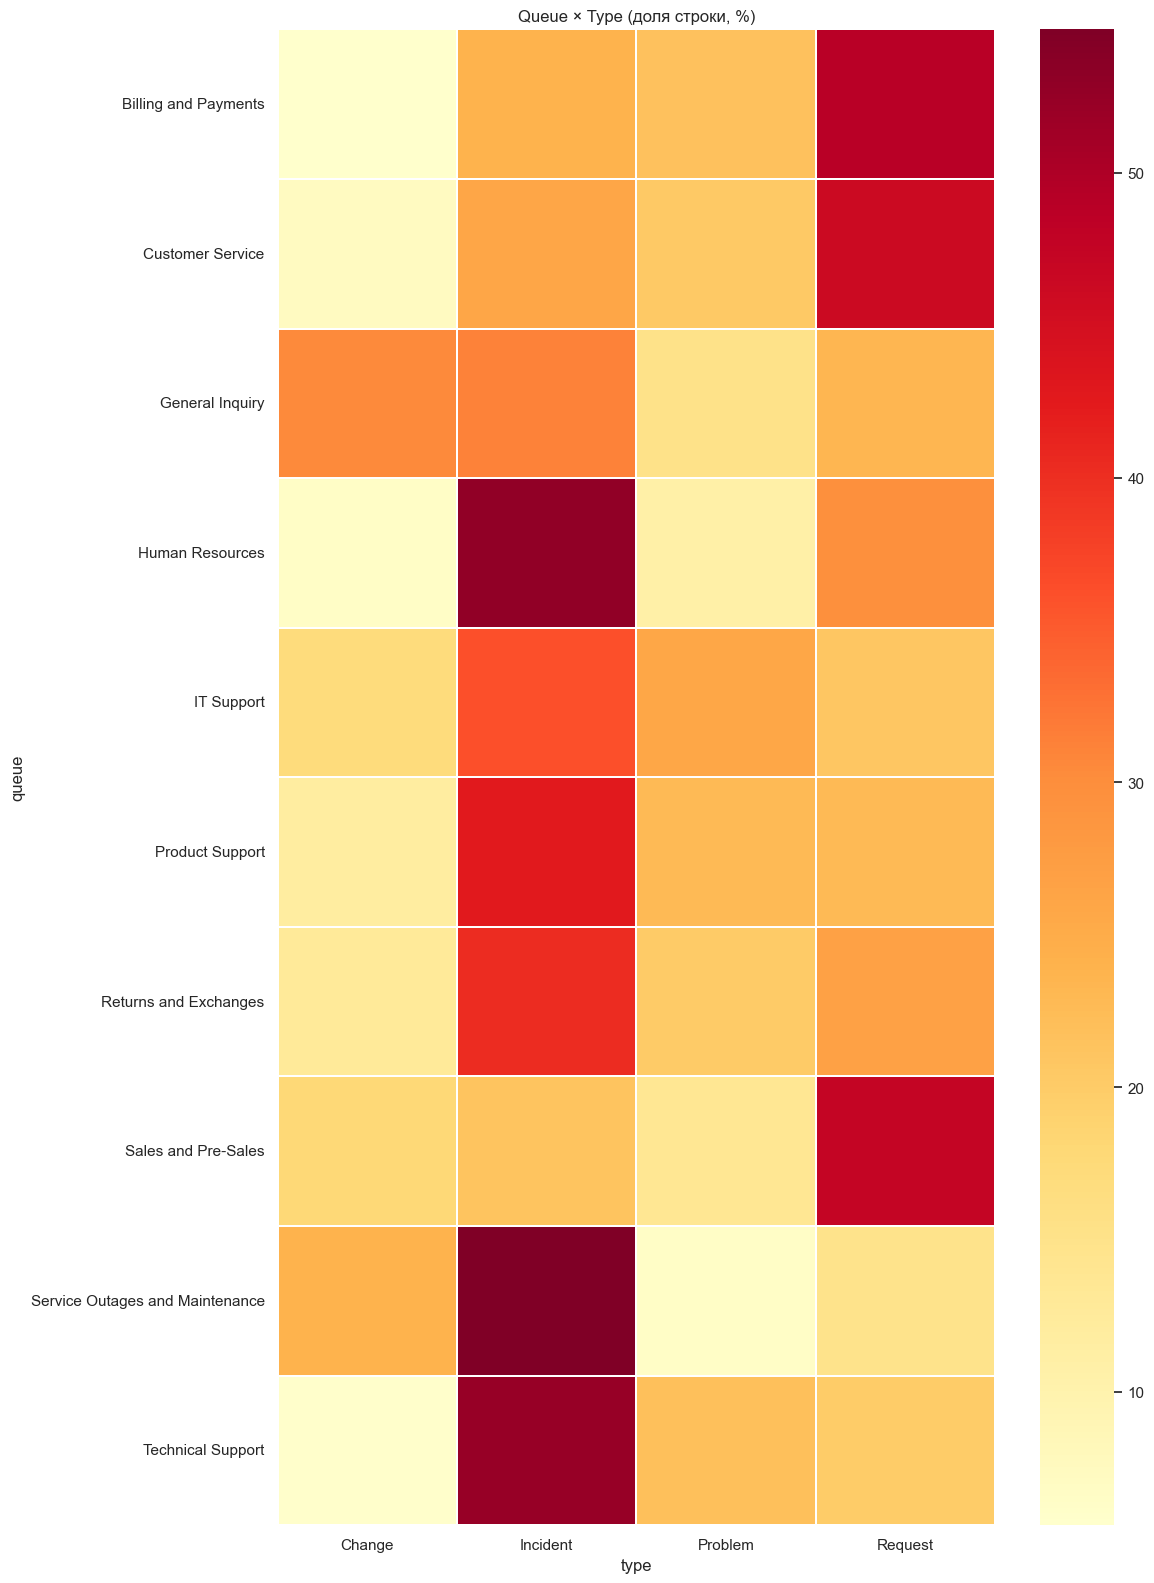

In [ ]:

for target in ["priority", "type"]:
    ct = pd.crosstab(df["queue"], df[target], normalize="index") * 100
    fig, ax = plt.subplots(figsize=(12, 16))
    sns.heatmap(ct, annot=False, cmap="YlOrRd", ax=ax, linewidths=0.1)
    ax.set_title(f"Queue × {target.capitalize()} (доля строки, %)")
    plt.tight_layout()
    # plt.savefig(f"eda_queue_{target}_heatmap.png", dpi=130)


In [44]:
df["text"] = df["subject"].fillna("") + " ||| " + df["body"].fillna("")

dupes = df.groupby("text")["queue"].nunique()
ambiguous = dupes[dupes > 1]
print(f"Уникальных текстов с >1 разной очередью: {len(ambiguous)}")
print(f"Это потенциальный 'шум' в разметке: {len(ambiguous)/len(df)*100:.2f}% примеров")


Уникальных текстов с >1 разной очередью: 0
Это потенциальный 'шум' в разметке: 0.00% примеров


## **Выводы**



* **Датасет хорошо подходит для текстовой классификации:** тексты в тикетах в основном короткие, а длины комфортны и для TF-IDF, и для BERT. Ограничение по 512 токенам почти не является проблемой

* **Главная сложность задачи — сильный дисбаланс в "queue" :** несколько крупных очередей собирают основную массу тикетов, а остальные представлены заметно слабее. Поэтому именно предсказание очереди становится самым трудным местом задачи

* **Распределения "priority" и "type" выглядят реалистично для support-домена:** чаще всего встречаются тикеты со средним и высоким приоритетом, а среди типов доминируют Incident и Request. При этом пропуски в "type" добавляют шум в разметку

* **Целевые переменные связаны между собой:** "type", "priority" и "queue" не независимы, а отражают общую структуру обращений. Это делает multitask-подход прикольным решением 







# **А что там по моделям, Шкипер?**

Это то, ради чего мы собрались

Моя позиция такая, тк у нас НЕ соревновательное дз, то почему бы не попробовать попробовать КАК МОЖНО БОЛЬШЕ интересного, а не просимулировать 3 модели --> впихнуь в тетрадку и сказать "Я сделялъ" 

Это дз больше про разнообразие подходов, различные идеи , а не про програмиирование....

Изначально, я хотел запихнуть в этот файл все модели то что у меня получились (примерно около 20 штук), которые я вымучил, прогоняя на своей CPU тк храню свои лимиты по GPU 

Но я посидел подумал, а зачем тебе это, проще реально вывести все резы (по факту я часть моделей убрал) + и дать некоторые коментарии по моделям 

Мини-комментарии: 

Многие параметры к моделям выбирались ввиду следующий ограничений:

- обучение на CPU (да да...об этом я писал выше)
- время (тк все очень и очень долго)
- сильная весенняя апатия 

| Модель | Почему прикольная |
|---|---|
| TF-IDF + MLP (manual) | Проверяет, даст ли небольшая нейросеть что-то сверх классических линейных моделей на тех же sparse-признаках. Полезна как честный эксперимент “а если сделать чуть сложнее”. |
| TF-IDF + LogReg | Сильный и очень быстрый бейзлайн для текстовой классификации: просто обучается, хорошо интерпретируется и часто даёт surprisingly высокий результат. |
| TF-IDF + LinearSVC | Один из самых надёжных методов на разреженных текстовых признаках: часто сильнее LogReg, при этом остаётся быстрым и стабильным. |
| SBERT + LogReg | Использует семантические эмбеддинги, поэтому лучше ловит смысл текста, а не только совпадения слов и n-грамм. |
| SBERT + LightGBM | Комбинирует плотные эмбеддинги и бустинг, поэтому может находить более сложные нелинейные зависимости, чем простая линейная модель. |
| mBERT partial FT | Компромиссный вариант fine-tuning: дообучается только часть модели, поэтому адаптация идёт дешевле, чем full FT. |
| mBERT full FT | Самый полный способ адаптации трансформера под задачу: все веса подстраиваются под данные, что даёт максимальный потенциальный потолок качества. |
| mBERT LoRA | Параметр-эффективное дообучение: позволяет адаптировать большую модель с меньшими затратами по памяти и вычислениям. |
| mBERT frozen improved | Трансформер работает как фиксированный экстрактор признаков, а улучшения вносятся сверху; хороший способ проверить, сколько даёт сам encoder без полного fine-tuning. |
| FastText + LogReg | Быстрый и лёгкий способ получить плотные текстовые представления; удобен как сильный недорогой baseline. |
| Hybrid TF-IDF + SBERT | Объединяет точные лексические признаки TF-IDF и семантику SBERT, поэтому может брать лучшее сразу из двух подходов. |

# **Итоговая таблица**

Могут быть косяки тк мои шалавливые ручки - это правили, но думаю посыл будет ясен 

Моя цель была следующей, сначала я хотел вывести график за графиком и расписывать мол почему получились эти мпетрики и тд, но потом я понял, мне бы самому было бы скучно и не интересно читать, поэтому выведу все разом, а внизу напишу выводы 

 [auto-scan] Обнаружена новая модель: model5_mbert_frozen
 ⚠️ TF-IDF + MLP (manual) — results.csv не найден
 ✓ TF-IDF + LogReg
 ✓ TF-IDF + LinearSVC
 ✓ SBERT + LogReg
 ✓ SBERT + LightGBM
 ✓ mBERT partial FT
 ✓ mBERT full FT
 ✓ mBERT LoRA
 ✓ mBERT frozen improved
 ⚠️ mBERT frozen CPU v2 — results.csv не найден
 ✓ FastText + LogReg
 ✓ Hybrid TF-IDF + SBERT
 ✓ Model5 Mbert Frozen

═══════════════════════════════════════════════════════════════════════════════════════════════
 📊 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ | TEST SET
 Score = 0.70 × MacroF1(queue) + 0.15 × Acc(priority) + 0.15 × Acc(type)
═══════════════════════════════════════════════════════════════════════════════════════════════


Модель,MacroF1(q) ↑,Acc(queue),Acc(prio),Acc(type),Score ★
Hybrid TF-IDF + SBERT,0.9133,0.6929,0.6910,0.8941,0.8770
TF-IDF + LinearSVC,0.8908,0.6754,0.6867,0.8920,0.8604
TF-IDF + LogReg,0.8627,0.6050,0.6351,0.8836,0.8317
FastText + LogReg,0.8591,0.6173,0.6105,0.8698,0.8235
SBERT + LightGBM,0.8358,0.6706,0.6231,0.8750,0.8098
mBERT full FT,0.8154,0.4628,0.5310,0.8460,0.7774
mBERT partial FT,0.8071,0.4389,0.5185,0.8378,0.7684
mBERT LoRA,0.7381,0.3976,0.4899,0.8265,0.7141
SBERT + LogReg,0.7196,0.4059,0.4497,0.8078,0.6924
mBERT frozen improved,0.5131,0.4331,0.4991,0.8188,0.5569


 🥇 Hybrid TF-IDF + SBERT                              Score = 0.8770
 🥈 TF-IDF + LinearSVC                                 Score = 0.8604
 🥉 TF-IDF + LogReg                                    Score = 0.8317

──────────────────────────────────────────────────────────────────────────────────────────
 📊 CONFIDENCE ANALYSIS
──────────────────────────────────────────────────────────────────────────────────────────


,TF-IDF + LogReg,TF-IDF + LinearSVC,SBERT + LogReg,SBERT + LightGBM,mBERT partial FT,mBERT full FT,mBERT LoRA,mBERT frozen improved,FastText + LogReg,Hybrid TF-IDF + SBERT,Model5 Mbert Frozen
100,0.8317,0.8604,0.6924,0.8098,0.7684,0.7774,0.7141,0.5569,0.8235,0.8770,0.2656
90,0.8540,0.8760,0.7012,0.8332,0.7736,0.7826,0.7186,0.6190,0.8328,0.8904,0.2725
80,0.8646,0.8869,0.7082,0.8484,0.7783,0.7858,0.7233,0.6535,0.8417,0.8992,0.2773
70,0.8755,0.8990,0.7166,0.8658,0.7826,0.7916,0.7274,0.6783,0.8542,0.9099,0.2872
60,0.8882,0.9129,0.7249,0.8812,0.7884,0.7971,0.7324,0.6971,0.8629,0.9216,0.2836
50,0.9008,0.9246,0.7396,0.8968,0.7997,0.8073,0.7387,0.7111,0.8773,0.9320,0.2961
40,0.9135,0.9382,0.7563,0.9186,0.8144,0.8215,0.7502,0.7245,0.8875,0.9488,0.3003
30,0.9269,0.9553,0.7865,0.9376,0.8346,0.8447,0.7763,0.7295,0.9040,0.9616,0.3102


,TF-IDF + LogReg,TF-IDF + LinearSVC,SBERT + LogReg,SBERT + LightGBM,mBERT partial FT,mBERT full FT,mBERT LoRA,mBERT frozen improved,FastText + LogReg,Hybrid TF-IDF + SBERT,Model5 Mbert Frozen
100,0.8627,0.8908,0.7196,0.8358,0.8071,0.8154,0.7381,0.5131,0.8591,0.9133,0.1199
90,0.8903,0.9086,0.7298,0.8667,0.8121,0.8194,0.7428,0.6021,0.8651,0.9229,0.1313
80,0.9010,0.9185,0.7373,0.8849,0.8167,0.8200,0.7469,0.6509,0.8713,0.9280,0.1411
70,0.9116,0.9297,0.7455,0.9045,0.8192,0.8237,0.7500,0.6850,0.8819,0.9342,0.1575
60,0.9217,0.9424,0.7525,0.9202,0.8234,0.8277,0.7531,0.7089,0.8885,0.9422,0.1535
50,0.9329,0.9523,0.7663,0.9363,0.8313,0.8337,0.7560,0.7254,0.8992,0.9484,0.1703
40,0.9441,0.9638,0.7823,0.9582,0.8397,0.8446,0.7649,0.7407,0.9044,0.9623,0.1771
30,0.9549,0.9774,0.8131,0.9736,0.8572,0.8690,0.7901,0.7432,0.9196,0.9693,0.1885


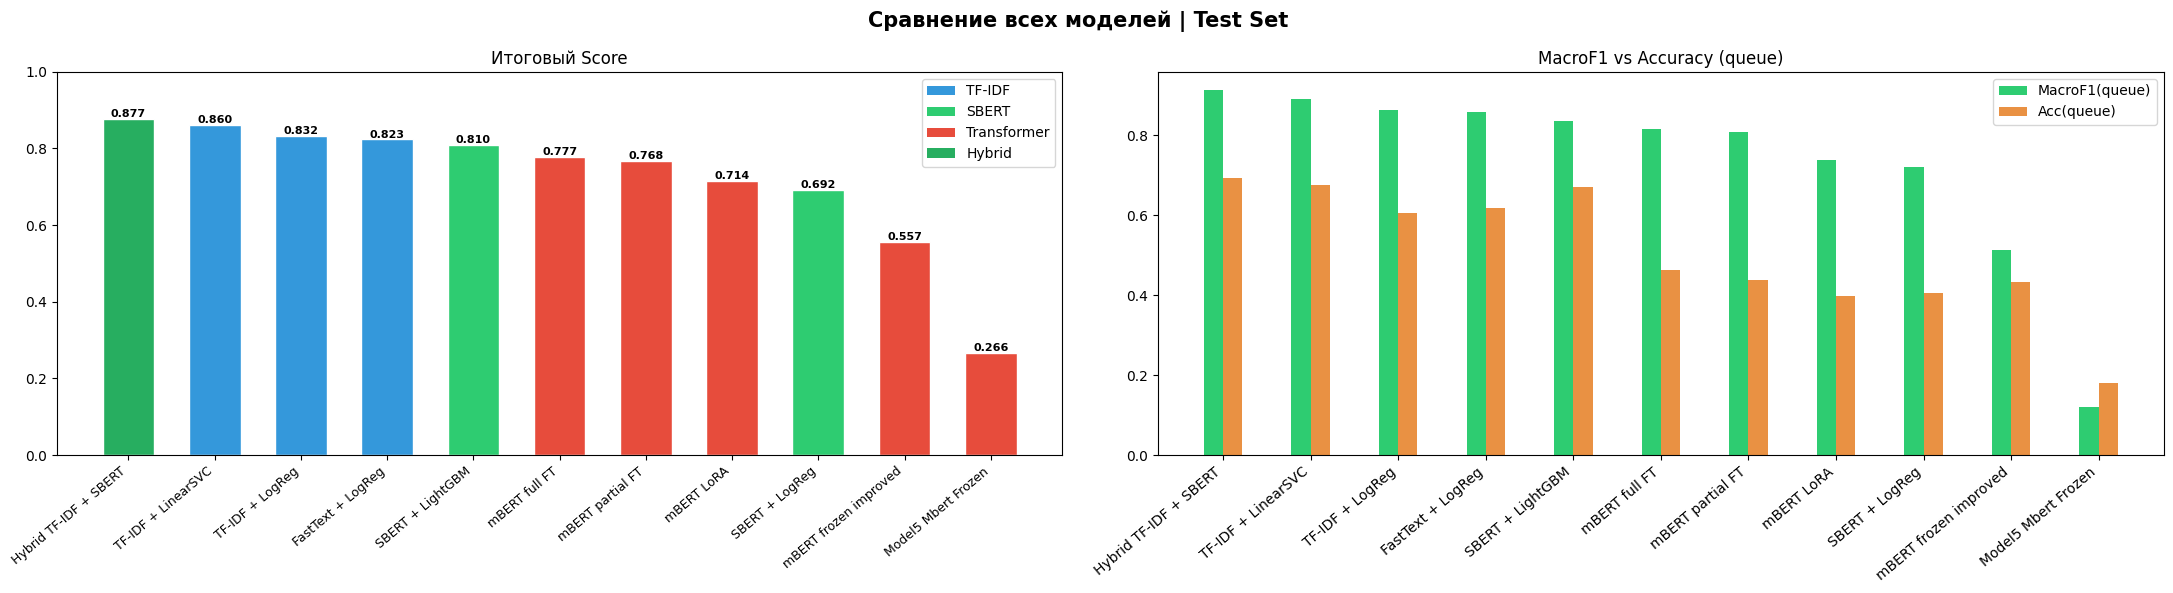

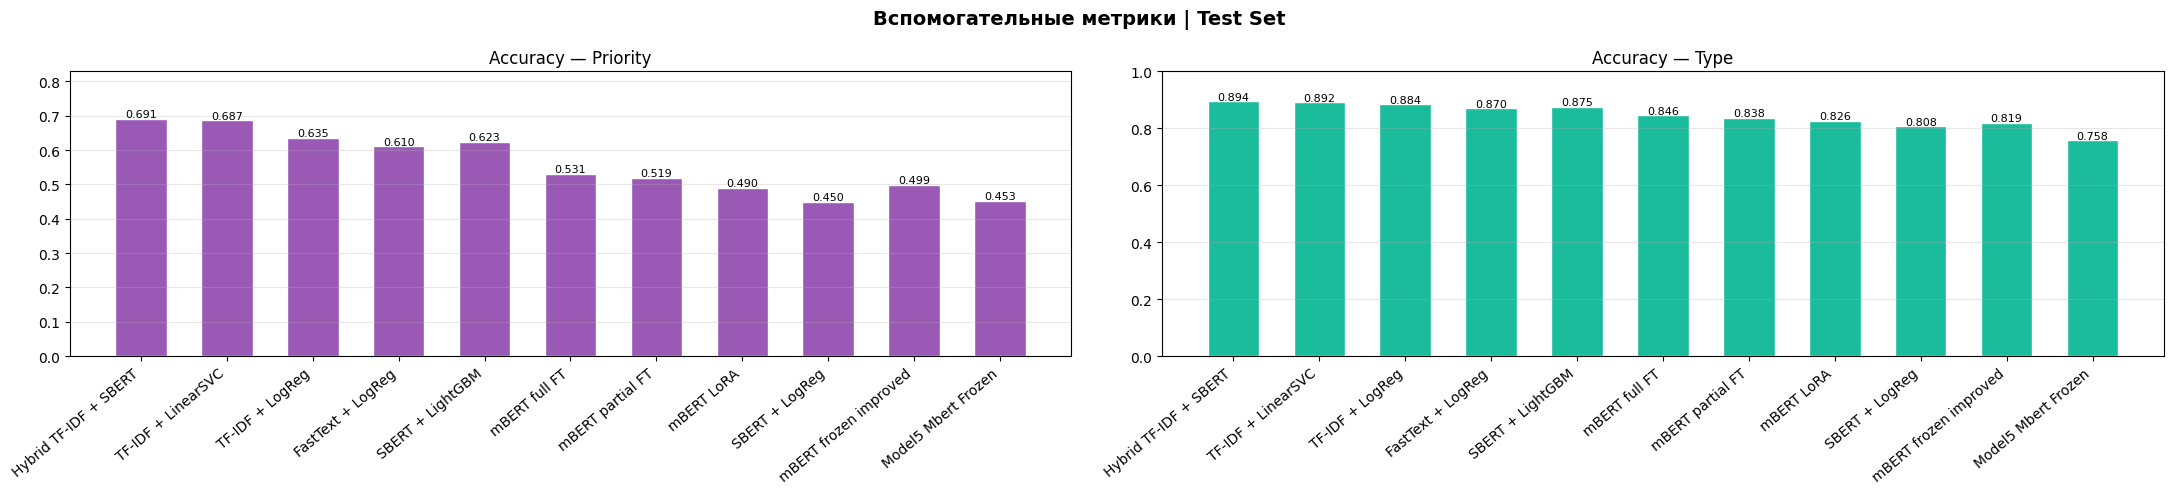

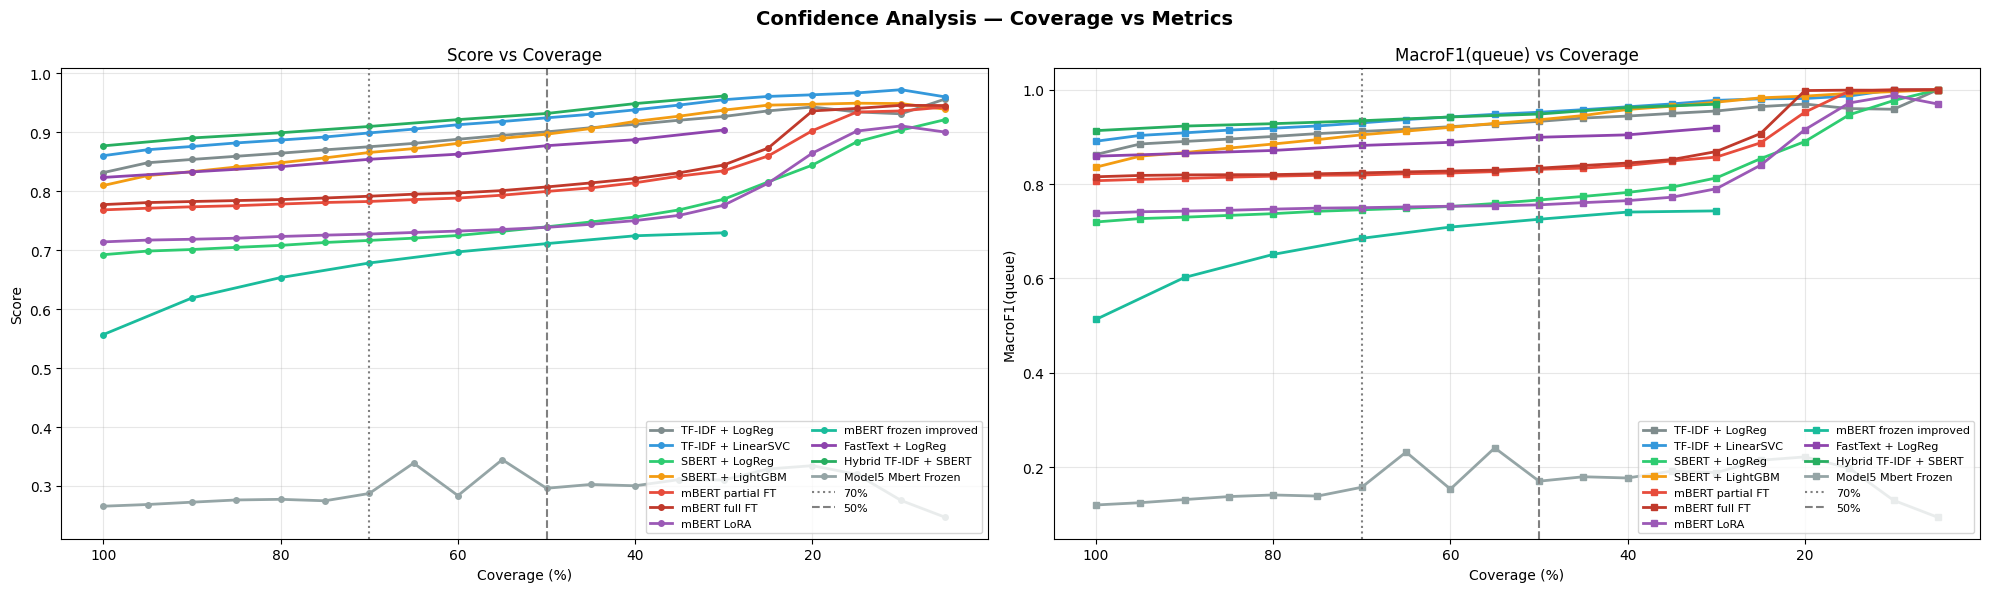


 Итоговый CSV → artifacts/all_models_results.csv
 График сравнения     → artifacts/final_comparison.png
 График вспомогат.    → artifacts/final_comparison_aux.png
 График confidence    → artifacts/final_confidence_comparison.png

Всего моделей: 11
Лучшая модель: Hybrid TF-IDF + SBERT → Score = 0.8770


In [11]:

# ██ ФИНАЛЬНАЯ ТАБЛИЦА — читает артефакты из artifacts/ (у меня там 15 гб артифактов, поэттому сдаю и чищу все!)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

ARTIFACTS = Path("artifacts")
W_Q, W_P, W_T = 0.70, 0.15, 0.15


MODEL_SLUGS = {
    "tfidf_mlp":                "TF-IDF + MLP (manual)",
    "model1_tfidf_logreg":      "TF-IDF + LogReg",
    "model2_tfidf_svc":         "TF-IDF + LinearSVC",
    "model3_sbert_logreg":      "SBERT + LogReg",
    "model4_sbert_lgbm":        "SBERT + LightGBM",
    "model5_mbert_partialft":   "mBERT partial FT",
    "model6_mbert_fullft":      "mBERT full FT",
    "model7_mbert_lora":        "mBERT LoRA",
    "model8_mbert_frozen_improved": "mBERT frozen improved",
    "mbert_frozen_cpu_v2":      "mBERT frozen CPU v2",
    "model9_fasttext":          "FastText + LogReg",
    "model10_hybrid_tfidf_sbert": "Hybrid TF-IDF + SBERT",   # лучшая
}


CONF_COLORS = {
    "tfidf_mlp":                "#bdc3c7",
    "model1_tfidf_logreg":      "#7f8c8d",
    "model2_tfidf_svc":         "#3498db",
    "model3_sbert_logreg":      "#2ecc71",
    "model4_sbert_lgbm":        "#f39c12",
    "model5_mbert_partialft":   "#e74c3c",
    "model6_mbert_fullft":      "#c0392b",
    "model7_mbert_lora":        "#9b59b6",
    "model8_mbert_frozen_improved": "#1abc9c",
    "mbert_frozen_cpu_v2":      "#16a085",
    "model9_fasttext":          "#8e44ad",
    "model10_hybrid_tfidf_sbert": "#27ae60",   # выделяем победителя
}


GROUPS = {
    "TF-IDF": ["tfidf_mlp", "model1_tfidf_logreg", "model2_tfidf_svc", "model9_fasttext"],
    "SBERT":  ["model3_sbert_logreg", "model4_sbert_lgbm"],
    "Transformer": [
        "model5_mbert_partialft", "model6_mbert_fullft",
        "model7_mbert_lora", "model8_mbert_frozen_improved", "mbert_frozen_cpu_v2"
    ],
    "Hybrid": ["model10_hybrid_tfidf_sbert"]
}

GROUP_COLORS = {
    "TF-IDF": "#3498db",
    "SBERT": "#2ecc71",
    "Transformer": "#e74c3c",
    "Hybrid": "#27ae60"
}


def get_group_color(slug):
    for group, slugs in GROUPS.items():
        if slug in slugs:
            return GROUP_COLORS[group]
    return "#95a5a6"



# АВТО-СКАНИРОВАНИЕ
_known_slugs = set(MODEL_SLUGS.keys())

for _p in sorted(ARTIFACTS.iterdir()):
    if not _p.is_dir() or not (_p / "results.csv").exists():
        continue
    slug = _p.name
    if slug not in _known_slugs:
        MODEL_SLUGS[slug] = slug.replace("_", " ").title()
        CONF_COLORS[slug] = "#95a5a6"
        if "hybrid" in slug.lower():
            GROUPS["Hybrid"].append(slug)
        elif "fasttext" in slug.lower():
            GROUPS["TF-IDF"].append(slug)
        else:
            GROUPS["Transformer"].append(slug)
        print(f" [auto-scan] Обнаружена новая модель: {slug}")



# СБОР + НОРМАЛИЗАЦИЯ

rows = []
for slug, name in MODEL_SLUGS.items():
    p = ARTIFACTS / slug / "results.csv"
    if p.exists():
        try:
            r = pd.read_csv(p).iloc[0].to_dict()
            r["method"] = name
            r["slug"] = slug
            rows.append(r)
            print(f" ✓ {name}")
        except Exception as e:
            print(f" ✗ Ошибка {name}: {e}")
    else:
        print(f" ⚠️ {name} — results.csv не найден")

df_res = pd.DataFrame(rows)

# Нормализация названий колонок
column_mapping = {
    'mf1_queue':'mf1_queue', 'macro_f1_queue':'mf1_queue', 'macrof1_queue':'mf1_queue',
    'f1_macro_queue':'mf1_queue', 'macro_f1':'mf1_queue', 'f1_queue':'mf1_queue',
    'acc_queue':'acc_queue', 'accuracy_queue':'acc_queue',
    'acc_priority':'acc_priority', 'acc_prio':'acc_priority', 'accuracy_priority':'acc_priority',
    'acc_type':'acc_type', 'accuracy_type':'acc_type',
    'score':'score', 'final_score':'score'
}
df_res = df_res.rename(columns=column_mapping)

if 'score' not in df_res.columns:
    df_res['score'] = (W_Q * df_res.get('mf1_queue',0) +
                       W_P * df_res.get('acc_priority',0) +
                       W_T * df_res.get('acc_type',0))

df_res = df_res.sort_values("score", ascending=False).reset_index(drop=True)



# ТАБЛИЦА + ТОП-3 (we are the champions, my friends 🎶)

print("\n" + "═"*95)
print(" 📊 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ | TEST SET")
print(" Score = 0.70 × MacroF1(queue) + 0.15 × Acc(priority) + 0.15 × Acc(type)")
print("═"*95)

available = [c for c in ['mf1_queue','acc_queue','acc_priority','acc_type','score'] if c in df_res.columns]

styled = (df_res[['method'] + available]
          .rename(columns={'method':'Модель', 'mf1_queue':'MacroF1(q) ↑',
                           'acc_queue':'Acc(queue)', 'acc_priority':'Acc(prio)',
                           'acc_type':'Acc(type)', 'score':'Score ★'})
          .style
          .format(precision=4)
          .background_gradient(subset=["Score ★"], cmap="Greens")
          .background_gradient(subset=["MacroF1(q) ↑"], cmap="Blues")
          .highlight_max(color="#d4edda")
          .hide(axis="index"))

try: display(styled)
except: print(df_res[['method'] + available].round(4))

# Топ-3
medals = ["🥇","🥈","🥉"] # ну блин, медальки это классика 
for i, row in df_res.head(3).iterrows():
    print(f" {medals[i]} {row['method']:<50} Score = {row['score']:.4f}")


# CONFIDENCE ТАБЛИЦЫ

COVER_PCTS = [100, 90, 80, 70, 60, 50, 40, 30]
conf_data = {}

for slug, name in MODEL_SLUGS.items():
    p = ARTIFACTS / slug / "confidence.csv"
    if p.exists():
        try:
            cdf = pd.read_csv(p)
            cdf = cdf[cdf["coverage_pct"].isin(COVER_PCTS)].copy()
            conf_data[name] = cdf.set_index("coverage_pct")
        except:
            pass

if conf_data:
    pivot_score = pd.DataFrame(index=COVER_PCTS)
    pivot_mf1 = pd.DataFrame(index=COVER_PCTS)
    for name, cdf in conf_data.items():
        pivot_score[name] = cdf.get("score", pd.NA)
        pivot_mf1[name]   = cdf.get("mf1_queue", pd.NA)

    print("\n" + "─"*90)
    print(" 📊 CONFIDENCE ANALYSIS")
    print("─"*90)
    try:
        display(pivot_score.style.format(precision=4).background_gradient(cmap="YlGn").highlight_max(axis=1))
        display(pivot_mf1.style.format(precision=4).background_gradient(cmap="Blues").highlight_max(axis=1))
    except:
        print(pivot_score.round(4))


# ГРАФИКИ (нужно больше графиков!!!)

slugs_sorted = df_res["slug"].tolist()
names_sorted = df_res["method"].tolist()
bar_colors = [get_group_color(s) for s in slugs_sorted]
n = len(names_sorted)
x = np.arange(n)
w = 0.22
fw = max(22, n * 1.9)

# Основной график
fig, axes = plt.subplots(1, 2, figsize=(fw, 6))
fig.suptitle("Сравнение всех моделей | Test Set", fontsize=15, fontweight="bold")

# Score
bars = axes[0].bar(x, df_res["score"], color=bar_colors, edgecolor="white", width=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names_sorted, rotation=40, ha="right", fontsize=9)
axes[0].set_title("Итоговый Score")
axes[0].set_ylim(0, min(1.0, df_res["score"].max() * 1.2))
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}", ha="center", fontsize=8, fontweight="bold")

axes[0].legend(handles=[Patch(facecolor=c, label=g) for g,c in GROUP_COLORS.items()], loc="upper right")

# MacroF1 vs Acc(queue)
if 'mf1_queue' in df_res.columns:
    axes[1].bar(x - w/2, df_res["mf1_queue"], w, label="MacroF1(queue)", color="#2ecc71")
if 'acc_queue' in df_res.columns:
    axes[1].bar(x + w/2, df_res["acc_queue"], w, label="Acc(queue)", color="#e67e22", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names_sorted, rotation=40, ha="right")
axes[1].set_title("MacroF1 vs Accuracy (queue)")
axes[1].legend()
plt.tight_layout()
plt.savefig(ARTIFACTS / "final_comparison.png", dpi=140, bbox_inches="tight")
plt.show()

# Вспомогательные
fig2, axes2 = plt.subplots(1, 2, figsize=(fw, 5))
fig2.suptitle("Вспомогательные метрики | Test Set", fontsize=14, fontweight="bold")
for ax, col, color, title in [
    (axes2[0], "acc_priority", "#9b59b6", "Accuracy — Priority"),
    (axes2[1], "acc_type", "#1abc9c", "Accuracy — Type")
]:
    if col in df_res.columns:
        bars = ax.bar(x, df_res[col], color=color, edgecolor="white", width=0.6)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}", ha="center", fontsize=8)
        ax.set_title(title)
        ax.set_ylim(0, min(1.0, df_res[col].max()*1.2))
        ax.set_xticks(x)
        ax.set_xticklabels(names_sorted, rotation=40, ha="right")
        ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(ARTIFACTS / "final_comparison_aux.png", dpi=140, bbox_inches="tight")
plt.show()

# Confidence Coverage
if conf_data:
    fig3, axes3 = plt.subplots(1, 2, figsize=(20, 6))
    fig3.suptitle("Confidence Analysis — Coverage vs Metrics", fontsize=14, fontweight="bold")
    for slug, name in MODEL_SLUGS.items():
        p = ARTIFACTS / slug / "confidence.csv"
        if not p.exists(): continue
        try:
            cdf = pd.read_csv(p).sort_values("coverage_pct")
            color = CONF_COLORS.get(slug, "gray")
            axes3[0].plot(cdf["coverage_pct"], cdf["score"], "-o", ms=4, lw=2, label=name, color=color)
            axes3[1].plot(cdf["coverage_pct"], cdf.get("mf1_queue", cdf["score"]), "-s", ms=4, lw=2, label=name, color=color)
        except: pass

    for ax, ylabel, title in [(axes3[0],"Score","Score vs Coverage"), (axes3[1],"MacroF1(queue)","MacroF1(queue) vs Coverage")]:
        ax.set_xlabel("Coverage (%)")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.invert_xaxis()
        ax.axvline(70, color="gray", ls=":", label="70%")
        ax.axvline(50, color="gray", ls="--", label="50%")
        ax.legend(fontsize=8, ncol=2, loc="lower right")
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(ARTIFACTS / "final_confidence_comparison.png", dpi=140, bbox_inches="tight")
    plt.show()



# ИТОГИ
out = ARTIFACTS / "all_models_results.csv"
df_res.drop(columns=["slug"], errors="ignore").to_csv(out, index=False)

print(f"\n Итоговый CSV → {out}")
print(f" График сравнения     → {ARTIFACTS}/final_comparison.png")
print(f" График вспомогат.    → {ARTIFACTS}/final_comparison_aux.png")
if conf_data:
    print(f" График confidence    → {ARTIFACTS}/final_confidence_comparison.png")

print(f"\nВсего моделей: {len(df_res)}")
if not df_res.empty and 'score' in df_res.columns:
    print(f"Лучшая модель: {df_res.iloc[0]['method']} → Score = {df_res.iloc[0]['score']:.4f}")

# **Вот вывел, дальше что? Щас распишу** (будеи много текста, поэтому сил)


Буду честным, я очень много ставил на bert --> но ставка не сыграла (внизу щас распишу)


## Выводы по экспериментам и по дз в целом

Главное мысль, которую можно донести что **качество в этой задаче определяется не только выбором модели, но и особенностями самих данных** (это мысль подтверждает почему Bert не сыграл упс, ниже объясню почему) 


Главная структурная особенность датасета — это сильный дисбаланс по queue (в EDA должен был про это запихнуть) Хотя экстремально маленьких классов здесь нет, разброс между самым частым и самым редким классом всё равно очень большой imbalance ratio = 61.7x. (это цифру я взял со своего же графика в EDA) Это означает, что задача маршрутизации в очередь остаётся самой чувствительной частью пайплайна: именно здесь модель должна различать много близких по смыслу классов, причём на неравномерных данных --> это неприкольно, окей идем дальше 

**Основная трудность — именно структура классов, а не слишком длинные тексты**

Я не буду говорить некоторые очевидные вещи, которые мы можем увидеть на графиках, например, что лучшей моделью оказалась **Hybrid TF-IDF + SBERT** (которую я придумал последней и по приколу тк безлайн *TF-IDF + LinearSVC** не давал мне душевного успокоения)


Главный содержательный вывод здесь в том, что в этой задаче **классические текстовые признаки оказались сильнее, чем “тяжёлые” трансформеры**. Это действительно немного неожиданно (для меня очень), потому что интуитивно хотелось бы ждать преимущества от mBERT, особенно в мультиязычной постановке (честно говоря я очень много ставил на то, что я морожу все слои, а затем доучиваю головы). Однако жизнь оказалась более жестокой и в этом случае тексты тикетов короткие, шаблонные и насыщены очень конкретной служебной лексикой (осуждаем) то для таких данных TF-IDF и линейные модели отлично ловят ключевые слова, устойчивые биграммы и повторяющиеся паттерны вроде названий проблем, процессов и сервисов, именно поэтому **TF-IDF + LinearSVC** оказался настолько сильным бейзлайном и почти догнал гибрид. В свою очередь, hybrid-подход победил за счёт того, что совместил два источника сигнала: TF-IDF дал точное совпадение по словам и фразам, а SBERT добавил семантику там, где формулировки тикетов различаются по поверхности, но совпадают по смыслу

Это довольно прикольное наблюдение (простая шалость вылилась в такой относительно непредсказуемый (по началу результат))


Отдельно интересен разрыв между двумя моделями на SBERT-эмбеддингах (я сначала не понимал почему) **SBERT + LightGBM** получил **0.8098**, тогда как **SBERT + LogReg** — только **0.6924** Но потом вспоминая К.Ю. Шилина я вспомнил следующее, что этот разрыв можно спокойно объяснить тк, сами эмбеддинги действительно полезны, но линейная модель использует их ограниченно, тогда как бустинг способен извлечь из плотных признаков более сложные зависимости. То есть семантическая информация в данных есть, но в чистом видемона работает хуже, чем комбинация семантики с лексическими признаками (бинго вопрос решен)


Самый неожиданный негативный результат связан с mBERT. Даже **full fine-tuning** не смог приблизиться к лидерам, а frozen-варианты провалились особенно сильно (что грустно) Наиболее показательный пример — **Model5 Mbert Frozen**, у которого **Macro-F1(queue) = 0.1199** при **Acc(type) = 0.7585** и итоговом **Score = 0.2656**. Это выглядит так, будто модель научилась различать только самые грубые и общие шаблоны, но не смогла адаптироваться к тонким различиям между очередями (но я походу с параметрами налажал в угоду обучения на CPU тк потом у меня была еще одна версия и она вела себя досточно неплохо = 75 скор )

Наиболее вероятное объяснение — ограниченные вычислительные ресурсы и неполноценный fine-tuning: В такой ситуации трансформер просто не успевает раскрыть свой потенциал, тогда как TF-IDF-бейзлайны дают сильный результат почти сразу - про это я писал неоднократно (это к вопросу про метрики и разнообразие моделей)


Практически очень важным оказался и **confidence-анализ** (я его даже сделал) Для лучшей модели **Hybrid TF-IDF + SBERT** итоговый **Score** растёт с **0.8770** на полном покрытии до **0.9320** при coverage 50%, **0.9488** при 40% и **0.9616** при 30% coverage. Аналогично **Macro-F1(queue)** растёт с **0.9133** до **0.9693**. Это важный сигнал, тк модель хорошо ранжирует собственную уверенность следовательно в реальном сценарии разумно использовать двухступенчатую схему — уверенные тикеты маршрутизировать автоматически, а менее уверенные отправлять на ручную проверку. Такой режим позволит получить очень высокое качество на части потока без необходимости полностью автоматизировать все случаи.

Итоговый вывод такой: в этой дз победила не самая сложная модель, а та, которая лучше соответствует структуре данных (пупупу EDA анализ прошел не зря) 

**Hybrid TF-IDF + SBERT** показал лучший баланс между качеством, устойчивостью и практической применимостью. Сильные результаты TF-IDF-моделей подтверждают, что для коротких и шаблонных support-текстов хорошие sparse-признаки остаются чрезвычайно конкурентоспособными 

Трансформеры в этой работе не провалились “в принципе”, но не смогли раскрыться в условиях CPU-обучения и ограниченного fine-tuning. Поэтому если говорить о рекомендации для практики, то на текущем этапе наиболее разумный выбор — **hybrid-модель или сильный TF-IDF baseline**, дополненный порогом по уверенности


Вывод выводов "Подарите мне GPU для решения задачек" 
